In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import Image

# Display image

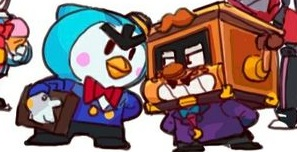

In [8]:
Image(filename="img.jpeg")

# Reading images

optional args:
* `cv2.IMREAD_GRAYSCALE` or `0` : Loads image in grayscale
* `cv2.IMREAD_COLOR` or `1` : Loads a color image. Any transparency will be neglected. (default)
* `cv2.IMREAD_UNCHANGED` or `-1`: Loads image as such including alpha channel

In [14]:
# Returns numpy 2d array
cb_img = cv2.imread("img.jpeg", 0)
print(cb_img)

[[220 122  78 ...  41  41  75]
 [155  73  69 ...  48  29  70]
 [ 78  71  95 ...  66  21  64]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


* Pixel values are in the range 0 to 255 because the image is represented by unsigned 8 bit integer

# Display Image attributes

In [17]:
print("Size:", cb_img.shape)
print("Data type:", cb_img.dtype)

Size: (152, 297)
Data type: uint8


# Display with matplotlib

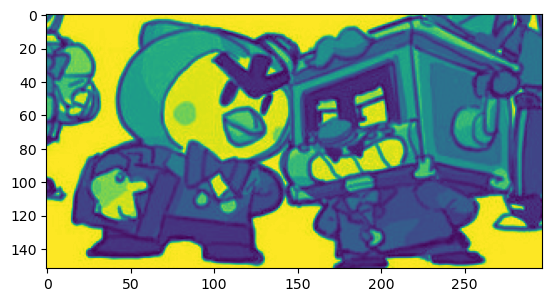

In [23]:
# argument: numpy array
plt.imshow(cb_img)

* It is actually a plot, and it is not the real size of the image
* The color has changed because it uses color maps to represent images, here it uses some other instead of the grayscale or original map
* You have to manually set the color map

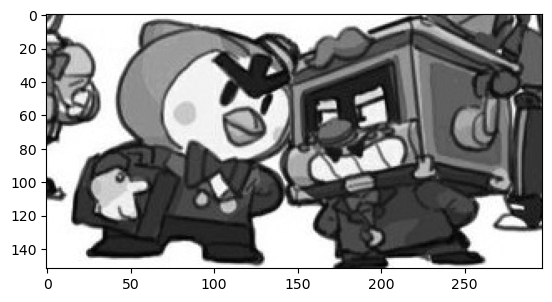

In [26]:
plt.imshow(cb_img, cmap='gray')

In [37]:
img = cv2.imread("img.jpeg", 1) # the same image

In [39]:
print("Shape:", img.shape)
print("Datatype:", img.dtype)

Shape: (152, 297, 3)
Datatype: uint8


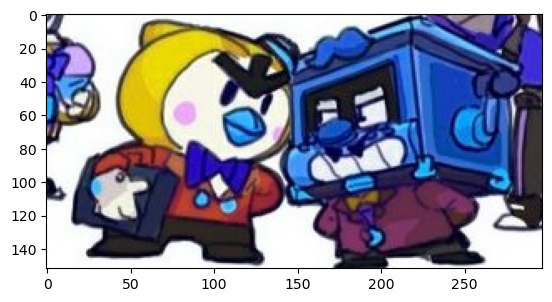

In [41]:
plt.imshow(img)

* The color changes because OpenCV uses a different format to store the images
* For RGB images, it uses BGR channel ordering
* So matplotlib expects it to be RGB, but we gave it BGR
* So we have to swap the order of channels

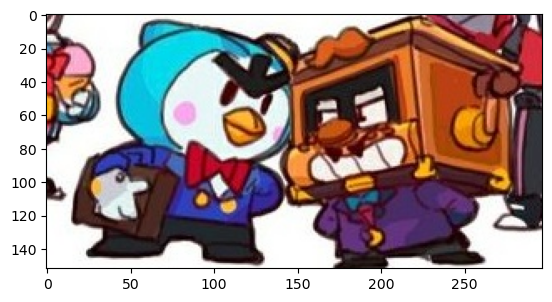

In [44]:
img_channel_reversed = img[:,:,::-1]
plt.imshow(img_channel_reversed)

# Splitting and merging color channels

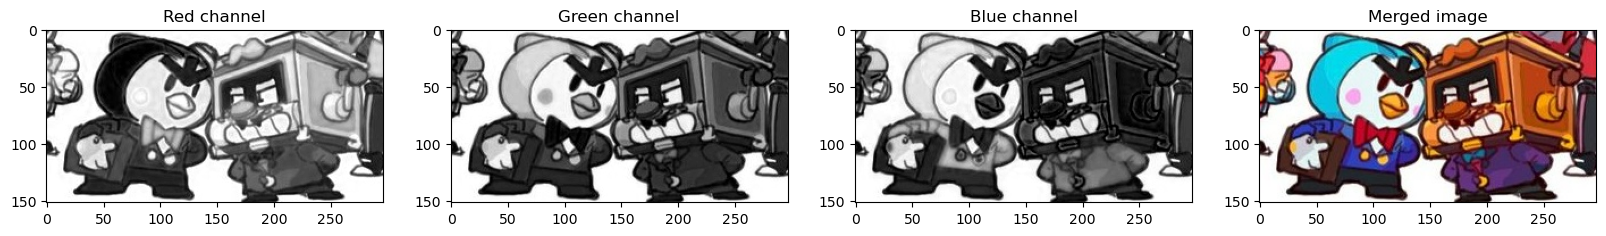

In [63]:
img = cv2.imread("img.jpeg", cv2.IMREAD_COLOR)
b, g, r = cv2.split(img)

plt.figure(figsize=[20,5])

plt.subplot(141);
plt.imshow(r, cmap="gray");
plt.title("Red channel");

plt.subplot(142);
plt.imshow(g, cmap="gray");
plt.title("Green channel");

plt.subplot(143);
plt.imshow(b, cmap="gray");
plt.title("Blue channel");

img_merged = cv2.merge((b,g,r))[:,:,::-1]

plt.subplot(144);
plt.imshow(img_merged);
plt.title("Merged image");

* 0 represents black (low intensity) and 255 represents white (high intensity)
* if you look at the penguins' blue skin in the red channel, it is very low(black), means there isn't much red component in that area, that's why it is darker (closer to 0)
* but in the blue and green channels, it more towards white (high intensity), means those two colors dominate in the original image
* Likewise, if you look at the bow tie, it's red in the original image, and in the red channel..its near to white (high intensity) means the red channel value is responsible to give the color in that area of the original image

# Converting into different color spaces

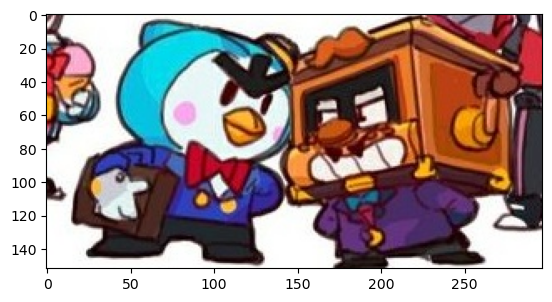

In [69]:
# Change BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

# Changing to HSV color space

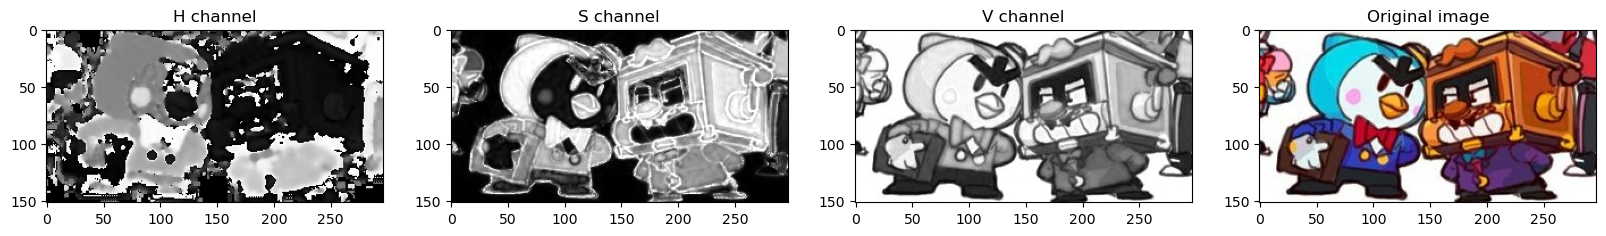

In [72]:
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

h,s,v = cv2.split(img_hsv)

plt.figure(figsize=[20,5])

plt.subplot(141);
plt.imshow(h, cmap="gray");
plt.title("H channel");

plt.subplot(142);
plt.imshow(s, cmap="gray");
plt.title("S channel");

plt.subplot(143);
plt.imshow(v, cmap="gray");
plt.title("V channel");

plt.subplot(144);
plt.imshow(img_rgb);
plt.title("Original image");

* HSV stands for Hue Saturation and Value
* Hue represents the actual color of the image
* Saturation represents how intense or pure that color is
* Value controls the brightness or lightness of that color

# Modifying individual channels

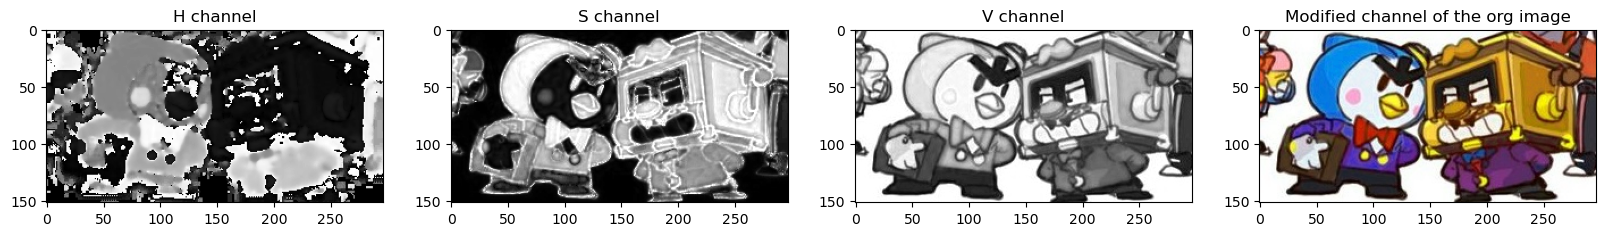

In [78]:
h_new = h + 10
img_merged = cv2.merge((h_new, s, v))
img_rgb = cv2.cvtColor(img_merged, cv2.COLOR_HSV2RGB)

plt.figure(figsize=[20,5])

plt.subplot(141);
plt.imshow(h_new, cmap="gray");
plt.title("H channel");

plt.subplot(142);
plt.imshow(s, cmap="gray");
plt.title("S channel");

plt.subplot(143);
plt.imshow(v, cmap="gray");
plt.title("V channel");

plt.subplot(144);
plt.imshow(img_rgb);
plt.title("Modified channel of the org image");

# Saving images

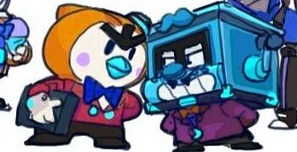

In [83]:
cv2.imwrite("save_img.jpg", img_rgb)
Image(filename="save_img.png")

# Displaying images with opencv in IDEs

```python
img = cv2.imread("image.jpg")

# displays the image for 8 secs
window1 = cv2.namedWindow("w1")
cv2.imshow(window1, img)
cv2.waitKey(8000)
cv2.destroyWindow(window1)

# displays the image forever...untill 'any' key is pressed
window2 = cv2.namedWindow("w2")
cv2.imshow(window2, img)
cv2.waitKey(0)
cv2.destroyWindow(window2)

# displays the image forever, untill 'q' is pressed
window3 = cv2.namedWindow("w3")
Alive = True

while Alive:
    cv2.imshow(window3, img)
    keypress = cv2.waitKey(1)
    if keypress == ord('q'):
        Alive = False

cv2.destroyWindow(window1)
```

# Accessing individual pixels

In [4]:
# Returns numpy 2d array
cb_img = cv2.imread("img.jpeg", 0)
print(cb_img)

[[220 122  78 ...  41  41  75]
 [155  73  69 ...  48  29  70]
 [ 78  71  95 ...  66  21  64]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


In [9]:
print(cb_img[0,0])
print(cb_img[1,-1])

220
70


# Modifying image pixels

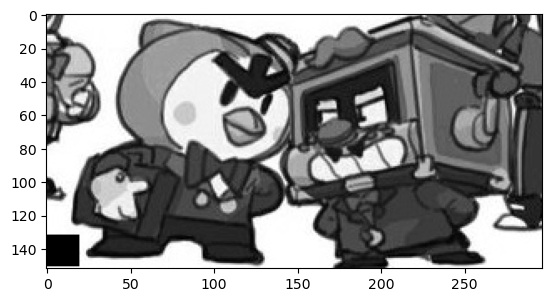

In [14]:
cb_img_copy = cb_img.copy()
cb_img_copy[-20:-1,:20] = 0
plt.imshow(cb_img_copy, cmap="gray")

# Cropping

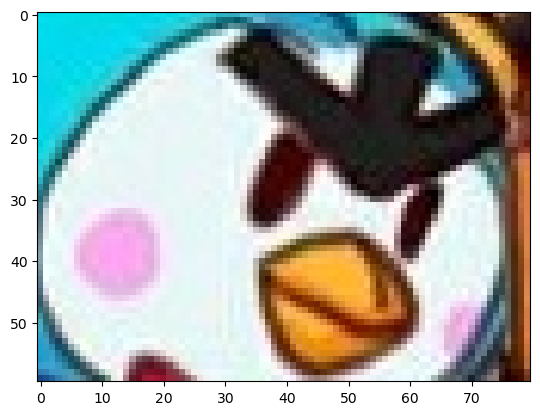

In [23]:
cb_img = cv2.imread("img.jpeg", 1)
cb_img_crop = cb_img[:,:,::-1]
cb_img_crop = cb_img_crop[20:80, 70:150]
plt.imshow(cb_img_crop)

# Resizing

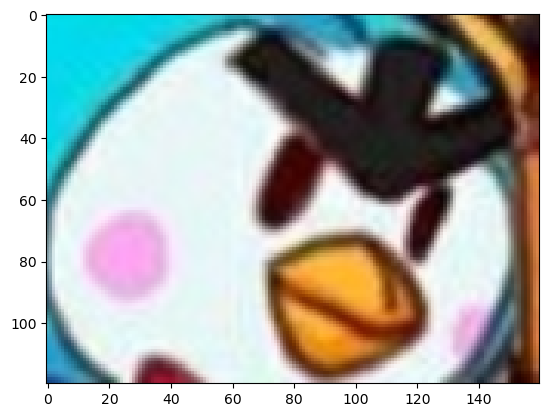

In [26]:
# fx and fy are scale factors along x and y axis
resized = cv2.resize(cb_img_crop, None, fx=2, fy=2)
plt.imshow(resized)

* Notice the image got bigger
* And it is less pixelated, as it uses some default interpolation methods to fill the blank rows and columns
* The default method is `cv2.INTER_LINEAR`

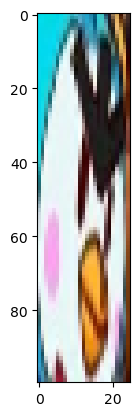

In [31]:
resized = cv2.resize(cb_img_crop, (25,100))
plt.imshow(resized)

# Resizing while maintaing aspect ratio

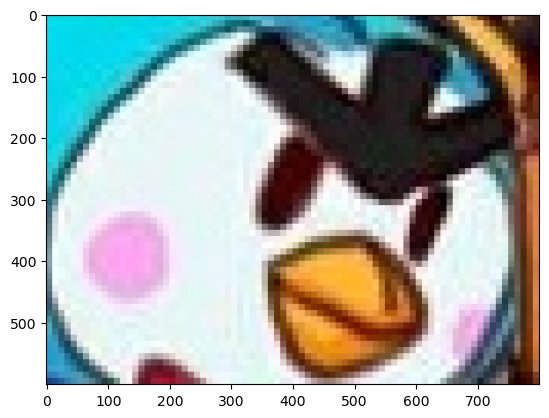

In [38]:
new_width = 800
aspect_ratio = new_width/cb_img_crop.shape[1]
new_height = int(cb_img_crop.shape[0]*aspect_ratio)

resized = cv2.resize(cb_img_crop, (new_width, new_height), interpolation=cv2.INTER_AREA)
plt.imshow(resized)

# flipping image

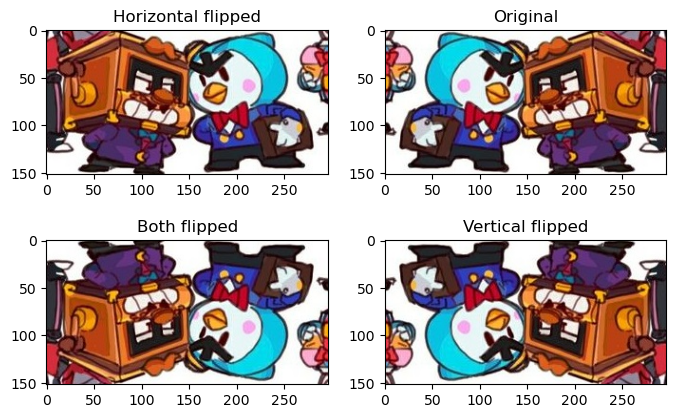

In [57]:
img_flip_hori = cv2.flip(cb_img[:,:,::-1], 1)
img_flip_vert = cv2.flip(cb_img[:,:,::-1], 0)
img_flip_both = cv2.flip(cb_img[:,:,::-1], -1)


plt.figure(figsize=[8,5])

plt.subplot(221);
plt.imshow(img_flip_hori);
plt.title("Horizontal flipped");

plt.subplot(224);
plt.imshow(img_flip_vert);
plt.title("Vertical flipped");

plt.subplot(223);
plt.imshow(img_flip_both);
plt.title("Both flipped");

plt.subplot(222);
plt.imshow(cb_img[:,:,::-1]);
plt.title("Original");